# 

In [165]:
import chromadb
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
import umap
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from collections import defaultdict

import json

In [166]:
import cohere
import csv
import numpy as np
import os
from dotenv import load_dotenv

In [167]:
COHERE_API_KEY=

In [136]:
import pandas as pd

# Constants
INPUT_CSV = "/home/robin/Downloads/alchemy_guests_3_23.csv"
OUTPUT_CSV = "/home/robin/Downloads/alchemy_guests_cleaned_data.csv"

# Load CSV
df = pd.read_csv(INPUT_CSV)
print(df.columns.tolist())

['api_id', 'name', 'first_name', 'last_name', 'email', 'phone_number', 'created_at', 'approval_status', 'custom_source', 'checked_in_at', 'amount', 'amount_tax', 'amount_discount', 'currency', 'coupon_code', 'eth_address', 'solana_address', 'survey_response_rating', 'survey_response_feedback', 'ticket_type_id', 'ticket_name', 'pronouns?', 'what’s something you’ve always wanted to learn but haven’t yet? (we’ll use this to match you with great conversation partners!)', "what's the last thing you worked on that you're proud of? (we’ll use this to match you with great conversation partners!)", "what's something you could talk about forever? (we’ll use this to match you with great conversation partners!)", "what's your hype song?", 'do you require any accommodations (e.g. dietary restrictions, accessibility needs)?']


In [137]:
# Column name in the raw CSV (based on your original schema)
accommodation_col = "do you require any accommodations (e.g. dietary restrictions, accessibility needs)?"

# Normalize column name (in case it's been renamed in your cleaned DataFrame)
for col in df.columns:
    if col.lower().startswith("do you require any accommodations"):
        accommodation_col = col
        break

# Initialize counters
halal_or_ramadan_count = 0
vegetarian_count = 0
vegan_count = 0

# Iterate through the column entries
for entry in df[accommodation_col].dropna():
    text = entry.lower()
    if "halal" in text or "ramadan" in text:
        halal_or_ramadan_count += 1
    if "vegetarian" in text:
        vegetarian_count += 1
    if "vegan" in text:
        vegan_count += 1

# Print results
print("🍽️ Dietary/Religious Accommodation Summary:")
print(f"🕌 Halal or Ramadan: {halal_or_ramadan_count}")
print(f"🥕 Vegetarian: {vegetarian_count}")
print(f"🌱 Vegan: {vegan_count}")


🍽️ Dietary/Religious Accommodation Summary:
🕌 Halal or Ramadan: 5
🥕 Vegetarian: 6
🌱 Vegan: 0


In [ ]:
# Step 1: Find the hype song column (in case the column name changed slightly)
hype_col = None
for col in df.columns:
    if "hype song" in col.lower():
        hype_col = col
        break

if hype_col is None:
    raise ValueError("Could not find the 'hype song' column in the DataFrame.")

# Step 2: Get attendee name column (optional)
name_col = None
for col in df.columns:
    if "name" in col.lower():
        name_col = col
        break

# Step 3: Print responses
print("🎶 Attendee Hype Songs:\n")
for i, row in df.iterrows():
    name = row.get(name_col, f"Attendee {i + 1}") if name_col else f"Attendee {i + 1}"
    hype_song = str(row.get(hype_col, "")).strip()
    if hype_song:
        print(f"{name}: {hype_song}")


In [139]:
selected_columns = {
    "name": "Name",
    "email": "Email",
    "what’s something you’ve always wanted to learn but haven’t yet? (we’ll use this to match you with great conversation partners!)": "Learning Interest",
    "what's the last thing you worked on that you're proud of? (we’ll use this to match you with great conversation partners!)": "Past Work",
    "what's something you could talk about forever? (we’ll use this to match you with great conversation partners!)": "Talk Forever",
    "what's your hype song?": "Hype Song"
}
df_cleaned = df[list(selected_columns.keys())].rename(columns=selected_columns)

df_cleaned = df_cleaned.drop_duplicates(subset=["Name"], keep="first")

df_cleaned = df_cleaned.replace(["NULL", "null", "None", "none"], "").fillna("")

non_matching_columns = ["Learning Interest", "Past Work", "Talk Forever", "Hype Song"]
df_cleaned = df_cleaned[~(df_cleaned[non_matching_columns] == "").all(axis=1)]

# save cleaned CSV
df_cleaned.to_csv(OUTPUT_CSV, index=False)

In [140]:
# to generate embeddings, 1) initialize cohere client (and chroma), 2) read answers from csv,
# 3) compute cosine similarity for each individual answer

load_dotenv()
#COHERE_API_KEY= os.getenv("COHERE_API_KEY")
co = cohere.Client(COHERE_API_KEY)

In [141]:
CSV_FILE = "/home/robin/Downloads/alchemy_guests_cleaned_data.csv"
# reading csv
attendees = {}
questions = []
with open(CSV_FILE, newline='') as attendees_csv:
    data = csv.reader(attendees_csv, delimiter=',', quotechar='"')
    header = next(data)  
    questions = header[1:] 
    
    for row in data:
        name = row[0]  # name
        #print(name)
        answers = row[1:]  # question responses
        attendees[name] = answers  # storing by name

#print(attendees)
#print(questions)

In [142]:
# Dictionary to store embeddings, emails, and answers clearly
person_embeddings = {} 

for name, answers in attendees.items():
    # Extract email (assumed always first answer)
    email = answers[0]

    # Exclude email (first column) and get only question answers
    question_answers = answers[1:]
    question_texts = questions[1:]

    # Filter out unanswered or null answers
    valid_answers = [a for a in question_answers if a.strip() and a.strip().upper() != "NULL"]
    valid_questions = [q for q, a in zip(question_texts, question_answers) if a.strip() and a.strip().upper() != "NULL"]

    if not valid_answers:
        continue  # Skip if no valid answers to questions

    # Generate embeddings for valid answers only (excluding emails)
    response = co.embed(
        texts=valid_answers,
        model="embed-english-light-v3.0",
        input_type="search_document"
    )

    embeddings = response.embeddings  # one per question-answer pair

    # Store embeddings with email clearly separated
    person_embeddings[name] = {
        "email": answers[0],
        "embeddings": {q: list(map(float, emb)) for q, emb in zip(valid_questions, embeddings)}
    }

# Save embeddings to JSON file
with open("embeddings.json", "w") as f:
    json.dump(person_embeddings, f, indent=4)

print("✅ Embeddings generated and stored (excluding emails from embeddings, but preserving email addresses).")



✅ Embeddings generated and stored (excluding emails from embeddings, but preserving email addresses).


In [168]:
# Load embeddings from JSON
with open("embeddings.json", "r") as f:
    person_embeddings = json.load(f)

In [169]:
attendee_names = list(person_embeddings.keys())
num_attendees = len(attendee_names)

# Define category mappings
categories = {
    "learn": "Learning Interest",
    "forever": "Talk Forever",
    "work": "Past Work"
}

CSV_OUTPUT_FILE = "attendee_clusters.csv"

### ======= HYPERPARAMETERS ======= ###
NUM_CLUSTERS = 3    # Number of clusters for Spectral Clustering

K_NEIGHBORS = 15      # Number of nearest neighbors for similarity graph

# Hyperparameters for similarity weighting
LEARNING_WEIGHT = 1.0
FOREVER_WEIGHT = 1.0
WORK_NEGATIVE_WEIGHT = -0.5
LEARN_FOREVER_WEIGHT = 2
WORK_LEARN_WEIGHT = 2
WORK_FOREVER_WEIGHT = 1
PCA_COMPONENTS = min(100, num_attendees)  

In [170]:
# Convert JSON data into structured format
attendee_embeddings = {}
category_embeddings = {key: [] for key in categories}

for name in attendee_names:
    attendee_embeddings[name] = {}
    embeddings_dict = person_embeddings[name]["embeddings"]

    for short_key, question_text in categories.items():
        if question_text in embeddings_dict:
            emb = np.array(embeddings_dict[question_text])
            attendee_embeddings[name][short_key] = emb
        else:
            print(f'ERROR: {name}, {question_text}')            
            emb_dim = len(next(iter(embeddings_dict.values())))
            attendee_embeddings[name][short_key] = np.zeros(emb_dim)
        
        category_embeddings[short_key].append(attendee_embeddings[name][short_key])

# Quick verification
print(f"✅ Sample attendee embeddings for {attendee_names[0]}:")
for cat, emb in attendee_embeddings[attendee_names[0]].items():
    print(f"  {cat}: {emb[:5]}...")  # just showing the first 5 elements

ERROR: Ahmed Sinjab, Talk Forever
ERROR: Atnasia Ibsa, Talk Forever
ERROR: Ali, Talk Forever
ERROR: Andrew Leest, Talk Forever
ERROR: Arianna Tan, Talk Forever
ERROR: Arthur Huang, Talk Forever
ERROR: Avan, Talk Forever
ERROR: Brenda Li, Talk Forever
ERROR: Chu Yi Yu, Talk Forever
ERROR: Chu Yi Yu, Past Work
ERROR: Daniel Wang, Talk Forever
ERROR: Gabi Foss, Talk Forever
ERROR: Hardeep Gambhir, Talk Forever
ERROR: James Kim, Talk Forever
ERROR: Jasmine, Talk Forever
ERROR: Josh Zucker, Talk Forever
ERROR: Lillian Wei, Talk Forever
ERROR: Lily Yang, Talk Forever
ERROR: Maya Lekhi, Talk Forever
ERROR: Pratham, Talk Forever
ERROR: Robin Hylands, Talk Forever
ERROR: Xavier Marc Desroches Desroches Borelly, Talk Forever
ERROR: Emily ✿, Talk Forever
ERROR: Om Gandhi, Learning Interest
ERROR: Om Gandhi, Talk Forever
✅ Sample attendee embeddings for Luisa Mi:
  learn: [-0.00315285 -0.02708435  0.05270386 -0.03796387  0.01268005]...
  forever: [ 0.02380371 -0.02980042  0.08190918 -0.0218811   0

In [171]:
def find_nearest_neighbor_embedding(name, missing_cat, attendee_embeddings):
    """
    Finds the nearest neighbor for a given attendee and missing category.
    Uses cosine similarity on the existing embeddings to determine the closest match.
    """
    similarities = []
    target_emb = attendee_embeddings[name]  # The attendee with missing data

    for other_name, other_emb in attendee_embeddings.items():
        if name == other_name:  # Skip self
            continue
        if missing_cat in other_emb and np.linalg.norm(other_emb[missing_cat]) > 0:
            # Compute similarity based on known embeddings (ignore missing categories)
            known_cats = [cat for cat in target_emb if cat != missing_cat and np.linalg.norm(target_emb[cat]) > 0]

            if not known_cats:  # Skip if no known categories for comparison
                continue

            # Compute average similarity across known categories
            similarity_scores = []
            for cat in known_cats:
                sim = cosine_similarity([target_emb[cat]], [other_emb[cat]])[0, 0]
                similarity_scores.append(sim)

            mean_similarity = np.mean(similarity_scores)
            similarities.append((other_name, mean_similarity))

    if similarities:
        # Get the most similar attendee
        best_match = max(similarities, key=lambda x: x[1])
        print(f"🔄 Replacing {name}'s missing {missing_cat} embedding with {best_match[0]}'s (Similarity: {best_match[1]:.3f})")
        return attendee_embeddings[best_match[0]][missing_cat]  # Return their embedding for missing category
    else:
        print(f"⚠️ No match found for {name}'s missing {missing_cat}")
        return None  # No valid match found

In [172]:
mean_embeddings = {}
for cat in categories:
    valid_embs = [attendee_embeddings[name][cat] for name in attendee_names 
                   if attendee_embeddings[name][cat] is not None]
    mean_embedding = np.mean(valid_embs, axis=0)
    mean_embedding /= np.linalg.norm(mean_embedding)  # Normalize embedding
    mean_embeddings[cat] = mean_embedding

for name in attendee_names:
    for cat in categories:
        emb = attendee_embeddings[name][cat]
        if np.linalg.norm(emb) == 0:  # If embedding is zero (i.e., missing)
            nearest_emb = find_nearest_neighbor_embedding(name, cat, attendee_embeddings)
            if nearest_emb is not None:
                attendee_embeddings[name][cat] = nearest_emb
                print(f"Replaced missing {cat} embedding for {name} using nearest neighbor.")
            else:
                attendee_embeddings[name][cat] = mean_embeddings[cat]
                print(f'Replaced zero or missing embedding for {name}, category {cat}')

# Verify embedding imputation
print(f"✅ After imputation, attendee embeddings for {attendee_names[0]}:")
for cat, emb in attendee_embeddings[attendee_names[0]].items():
    print(f"  {cat}: {emb[:5]}...")

🔄 Replacing Ahmed Sinjab's missing forever embedding with Siddhant Saraf's (Similarity: 0.518)
Replaced missing forever embedding for Ahmed Sinjab using nearest neighbor.
🔄 Replacing Atnasia Ibsa's missing forever embedding with Clara Chen's (Similarity: 0.680)
Replaced missing forever embedding for Atnasia Ibsa using nearest neighbor.
🔄 Replacing Ali's missing forever embedding with Joshua Brown's (Similarity: 0.491)
Replaced missing forever embedding for Ali using nearest neighbor.
🔄 Replacing Andrew Leest's missing forever embedding with Rhea George 's (Similarity: 0.639)
Replaced missing forever embedding for Andrew Leest using nearest neighbor.
🔄 Replacing Arianna Tan's missing forever embedding with Atnasia Ibsa's (Similarity: 0.610)
Replaced missing forever embedding for Arianna Tan using nearest neighbor.
🔄 Replacing Arthur Huang's missing forever embedding with Kathy Dong's (Similarity: 0.599)
Replaced missing forever embedding for Arthur Huang using nearest neighbor.
🔄 Replac

In [173]:
# Apply PCA separately for each category
for key in categories:
    if len(category_embeddings[key]) > 1:  # Ensure there is more than one sample
        category_embeddings[key] = np.array(category_embeddings[key])
        pca = PCA(n_components=min(PCA_COMPONENTS, num_attendees), random_state=42)
        reduced_embeddings = pca.fit_transform(category_embeddings[key])
        
        # Store the reduced embeddings for each attendee
        for i, name in enumerate(attendee_names):
            attendee_embeddings[name][key] = reduced_embeddings[i]
    
    print(f"Reduced {key} embeddings from {category_embeddings[key].shape[1]}D to {PCA_COMPONENTS}D.")

# Construct cross-category weighted similarity matrix
affinity_matrix = np.zeros((num_attendees, num_attendees))

#print(attendee_embeddings)

for i in range(num_attendees):
    for j in range(i, num_attendees):  # Compute only upper triangle (symmetric)
        name_i, name_j = attendee_names[i], attendee_names[j]
        emb_i, emb_j = attendee_embeddings[name_i], attendee_embeddings[name_j]

        total_similarity = 0

        # Same-category similarity
        if "learn" in emb_i and "learn" in emb_j:
            #print("learn:learn")
            total_similarity += LEARNING_WEIGHT * cosine_similarity([emb_i["learn"]], [emb_j["learn"]])[0][0]
            #print(f'emb i,j: {emb_i}, {emb_j}')
        if "forever" in emb_i and "forever" in emb_j:
            #print("forever:forever")
            total_similarity += FOREVER_WEIGHT * cosine_similarity([emb_i["forever"]], [emb_j["forever"]])[0][0]

        # "Work" self-comparison (encouraging diversity)
        if "work" in emb_i and "work" in emb_j:
            #print("work:work")
            if i == j:  # Comparing "work" with itself (dissimilarity)
                total_similarity += WORK_NEGATIVE_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["work"]])[0][0]
        
        # Cross-category similarities
        if "learn" in emb_i and "forever" in emb_j:
            #print("learn:forever")
            total_similarity += LEARN_FOREVER_WEIGHT * cosine_similarity([emb_i["learn"]], [emb_j["forever"]])[0][0]
        if "work" in emb_i and "learn" in emb_j:
            #print("work:learn")
            total_similarity += WORK_LEARN_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["learn"]])[0][0]
        if "work" in emb_i and "forever" in emb_j:
            #print("work:forever")
            total_similarity += WORK_FOREVER_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["forever"]])[0][0]

        # Fill in the matrix (ensuring symmetry)
        affinity_matrix[i, j] = total_similarity
        affinity_matrix[j, i] = total_similarity
        #print(total_similarity)

print("✅ Custom cross-category similarity matrix constructed.")

Reduced learn embeddings from 384D to 100D.
Reduced forever embeddings from 384D to 100D.
Reduced work embeddings from 384D to 100D.
✅ Custom cross-category similarity matrix constructed.


***Default Agglomerative Clustering***

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [175]:
### ======= STEP 1: Perform Agglomerative Clustering ======= ###
# Convert similarity matrix to a distance matrix (Agglomerative Clustering uses distances)
distance_matrix = 1 - affinity_matrix

# Perform Agglomerative Clustering
agglomerative_clusterer = AgglomerativeClustering(
    n_clusters=None,  # If None, uses distance threshold to find clusters
    distance_threshold=0.5,  # Adjust to control cluster granularity (lower = more clusters)
    metric="precomputed",  # Using precomputed affinity (cosine similarity transformed to distance)
    linkage="average"  # 'average' or 'complete' work well with cosine distance
)

labels = agglomerative_clusterer.fit_predict(distance_matrix)

# Store cluster assignments
attendee_cluster_assignments = {name: cluster for name, cluster in zip(attendee_names, labels)}

print(f"✅ Clustering complete! {len(set(labels))} clusters found.")

### ======= STEP 2: Save Cluster Assignments to CSV ======= ###
csv_output_file = "attendee_agglomerative_clusters.csv"

df_clusters = pd.DataFrame({
    "Attendee Name": attendee_names,
    "Cluster ID": labels
})

df_clusters.to_csv(csv_output_file, index=False)
print(f"📂 Cluster labels saved to {csv_output_file}!")

✅ Clustering complete! 16 clusters found.
📂 Cluster labels saved to attendee_agglomerative_clusters.csv!


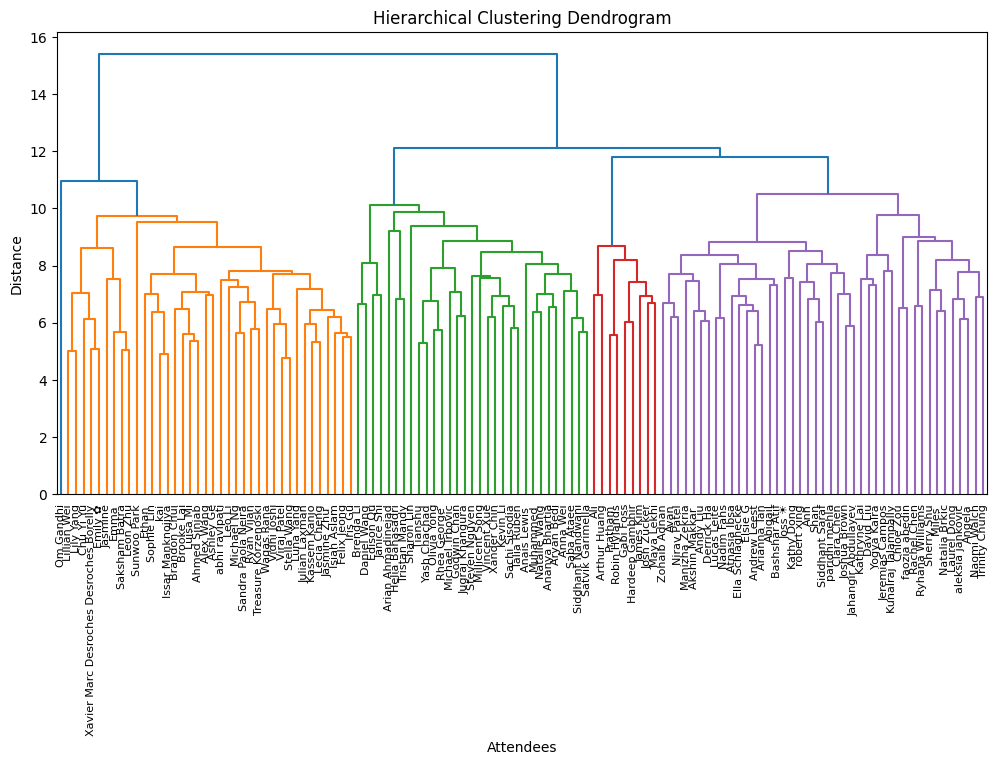

In [176]:
### ======= STEP 3: Dendrogram Visualization ======= ###
def plot_dendrogram(distance_matrix, attendee_names):
    """Plots a hierarchical clustering dendrogram for better cluster visualization."""
    linkage_matrix = linkage(distance_matrix, method="average")  # 'average' for cosine distance

    plt.figure(figsize=(12, 6))
    dendrogram(linkage_matrix, labels=attendee_names, leaf_rotation=90, leaf_font_size=8)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Attendees")
    plt.ylabel("Distance")
    plt.show()

# Plot Dendrogram
plot_dendrogram(distance_matrix, attendee_names)

In [152]:
# Plot full dendrogram
linkage_matrix = linkage(distance_matrix, method="average")
plt.figure(figsize=(20, 10))
d = dendrogram(
    linkage_matrix,
    labels=attendee_names,
    leaf_rotation=90,
    leaf_font_size=6,    # small font so all names fit
    color_threshold=None # no automatic coloring
)

plt.title("Full Agglomerative Clustering Dendrogram")
plt.xlabel("Attendee")
plt.ylabel("Distance")
plt.tight_layout()

# Save high‑resolution image
output_path = "full_attendee_dendrogram.png"
plt.savefig(output_path, dpi=300)
plt.close()

print(f"✅ Dendrogram saved to {output_path}")

✅ Dendrogram saved to full_attendee_dendrogram.png


In [153]:
import numpy as np
from scipy.cluster.hierarchy import linkage, to_tree
import copy

# Assume data is a NumPy array of shape (n_samples, n_features)
# Compute the linkage matrix (here we use the 'ward' method, but you may choose another)
Z = linkage(distance_matrix, method='ward')

# Convert the linkage matrix to a tree structure
root_node, node_list = to_tree(Z, rd=True)

# Add parent pointers to the dendrogram nodes
def add_parent_pointers(node, parent=None):
    node.parent = parent
    if not node.is_leaf():
        add_parent_pointers(node.left, node)
        add_parent_pointers(node.right, node)

add_parent_pointers(root_node)

# Helper function: get leaves of a node
def get_leaves(node):
    if node.is_leaf():
        return [node.id]
    else:
        return get_leaves(node.left) + get_leaves(node.right)

# Modified splitting function: return (leaves, [node]) pairs.
# For each node that is small enough, we return its leaves along with a list containing the node.
def split_tree_preserving_subtrees(node, min_cluster_size=4, max_cluster_size=6):
    """
    Recursively split the dendrogram into clusters, preferring whole subtrees when possible.
    Ensures clusters come from local tree structure (sisters stay together).
    """
    leaves = get_leaves(node)

    # If this entire subtree fits, accept it as a cluster
    if min_cluster_size <= len(leaves) <= max_cluster_size:
        return [(leaves, [node])]

    # If it's too small, return nothing (we’ll handle these stragglers in the merge phase)
    if len(leaves) < min_cluster_size:
        return [(leaves, [node])]  # Let the merge phase fix this

    # Otherwise it's too big — recursively split it
    clusters = []
    if node.left is not None:
        clusters.extend(split_tree_preserving_subtrees(node.left, min_cluster_size, max_cluster_size))
    if node.right is not None:
        clusters.extend(split_tree_preserving_subtrees(node.right, min_cluster_size, max_cluster_size))
    return clusters

# Perform the recursive splitting
final_clusters = split_tree_preserving_subtrees(root_node, min_cluster_size=4, max_cluster_size=6)

# Function to compute the dendrogram distance between two original nodes.
# This is defined as the linkage distance (node.dist) of their lowest common ancestor.
def dendrogram_distance(node1, node2):
    # Build a set of ancestors for node1 (using id() as a unique identifier)
    ancestors1 = {}
    current = node1
    while current is not None:
        ancestors1[id(current)] = current
        current = current.parent
    current = node2
    while current is not None:
        if id(current) in ancestors1:
            return current.dist
        current = current.parent
    return np.inf

# For merged clusters (which may contain more than one original node), 
# define the distance as the minimum dendrogram distance among any pair of original nodes.
def dendrogram_distance_cluster(cluster1, cluster2):
    min_d = np.inf
    for node1 in cluster1[1]:
        for node2 in cluster2[1]:
            d = dendrogram_distance(node1, node2)
            if d < min_d:
                min_d = d
    return min_d

# Function to find a candidate cluster to merge with a small cluster.
# Instead of using Euclidean or cosine distances, we search over all other final clusters
# and pick the one with the smallest dendrogram distance (i.e. the nearest in the dendrogram).
def find_candidate_for_merge(small_cluster, all_clusters, max_merged_size=6):
    small_size = len(small_cluster[0])
    candidate = None
    candidate_distance = np.inf
    for cluster in all_clusters:
        if cluster == small_cluster:
            continue
        merged_size = len(small_cluster[0]) + len(cluster[0])
        # Ensure that merging does not exceed our upper bound (here 6)
        if merged_size > max_merged_size:
            continue
        # Compute dendrogram distance between clusters
        d = dendrogram_distance_cluster(small_cluster, cluster)
        if d < candidate_distance:
            candidate_distance = d
            candidate = cluster
    return candidate

# Iteratively merge clusters with fewer than min_cluster_size leaves using dendrogram structure.
def merge_small_clusters_dendrogram(clusters, min_cluster_size=4, max_merged_size=6):
    clusters_merged = copy.copy(clusters)
    merged_flag = True
    while merged_flag:
        merged_flag = False
        # Use a copy of the list to iterate safely while modifying clusters_merged.
        for cluster in clusters_merged.copy():
            if len(cluster[0]) < min_cluster_size:
                candidate = find_candidate_for_merge(cluster, clusters_merged, max_merged_size)
                if candidate is not None:
                    # Merge the two clusters: combine the leaf lists and the node lists
                    new_leaves = cluster[0] + candidate[0]
                    new_nodes = cluster[1] + candidate[1]
                    new_cluster = (new_leaves, new_nodes)
                    # Remove the two original clusters and add the new merged cluster.
                    clusters_merged.remove(cluster)
                    clusters_merged.remove(candidate)
                    clusters_merged.append(new_cluster)
                    merged_flag = True
                    # Break out of the loop to restart, as the clusters list has changed.
                    break
    return clusters_merged

# Merge clusters that are too small using our dendrogram-based method.
final_merged_clusters = merge_small_clusters_dendrogram(final_clusters, min_cluster_size=3, max_merged_size=6)

# final_merged_clusters now contains tuples where the first element is the list of data point indices
# for each merged cluster. The second element holds the list of original dendrogram nodes that contributed.
print("Final merged clusters (each tuple's first element is the list of data point indices):")
for cluster in final_merged_clusters:
    print(cluster[0])

Final merged clusters (each tuple's first element is the list of data point indices):
[121, 66, 74, 86, 94, 107]
[34, 20, 21, 52, 68, 69]
[35, 99, 43, 46]
[22, 24, 0, 4, 8, 17]
[110, 112, 113, 105, 114]
[90, 47, 37, 44]
[70, 51, 59, 62, 65]
[106, 117, 85, 91]
[39, 56, 61, 73]
[111, 115, 101, 63, 104, 109]
[3, 42, 45]
[23, 28, 31, 50]
[77, 79, 97, 78, 96]
[1, 14, 48, 81, 11, 100]
[88, 93, 26, 116, 120]
[38, 41, 49, 58, 72]
[87, 92, 75, 98, 102]
[5, 12, 15, 19, 2, 32]
[18, 83, 33, 119]
[71, 6, 9, 40]
[60, 29, 118, 54, 64]
[84, 108, 30, 7, 13]
[10, 16, 57, 25, 53, 55]
[89, 95, 67, 82]
[27, 36, 103, 76, 80]


/tmp/ipykernel_74548/781011228.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20', len(unique_cluster_ids))
/tmp/ipykernel_74548/781011228.py:46: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/robin/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


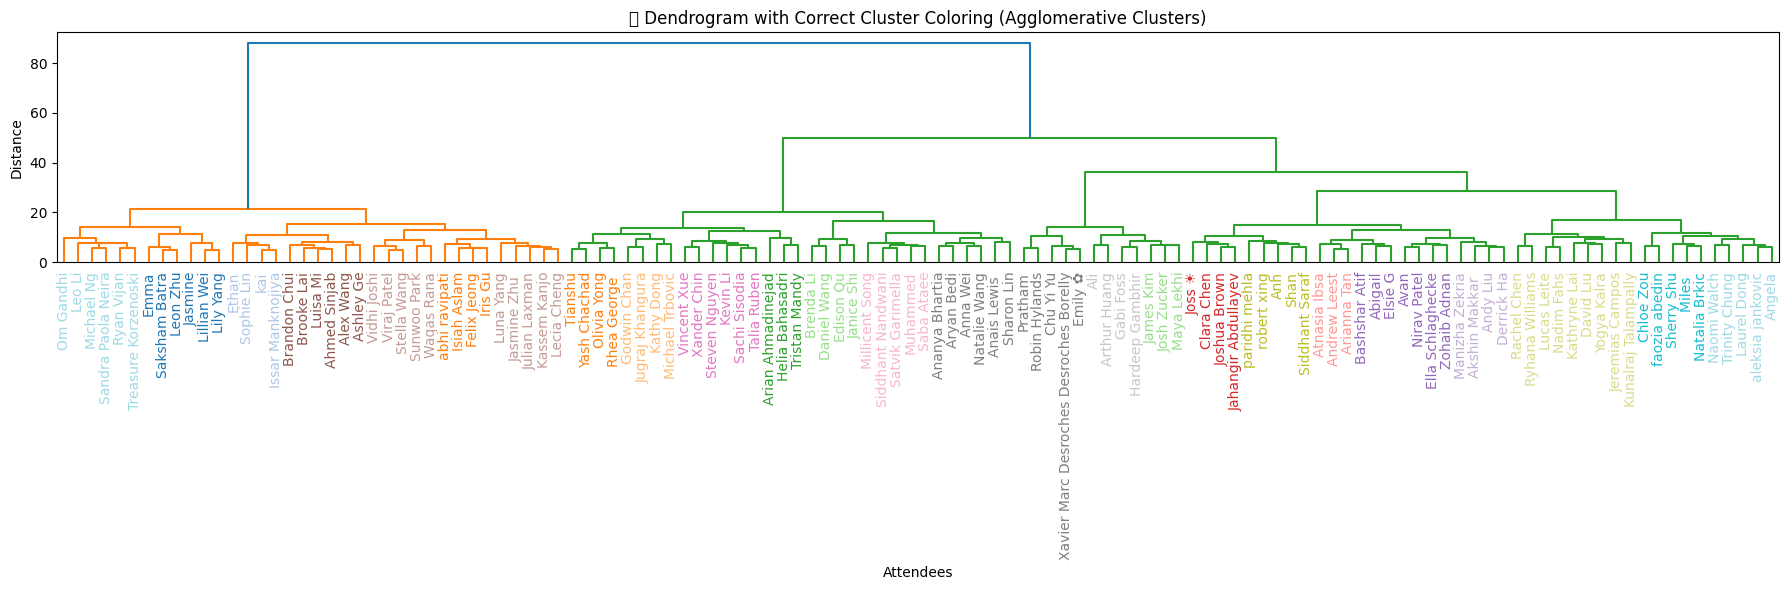

✅ Dendrogram saved to full_attendee_dendrogram_match.png


In [178]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import matplotlib.cm as cm

# === Reuse the correct linkage matrix used in the agglomerative clustering ===
linkage_matrix = Z  # Don't re-link; use the actual one from clustering

# === Step 1: Build index-to-cluster map from final_merged_clusters ===
index_to_cluster = {}
for cluster_id, (indices, _) in enumerate(final_merged_clusters):
    for idx in indices:
        index_to_cluster[idx] = cluster_id

# === Step 2: Color map for cluster IDs ===
unique_cluster_ids = sorted(set(index_to_cluster.values()))
color_map = cm.get_cmap('tab20', len(unique_cluster_ids))
cluster_id_to_color = {cid: color_map(i) for i, cid in enumerate(unique_cluster_ids)}

# === Step 3: Label function based on index ===
def label_func(idx):
    return attendee_names[idx]  # Only return name; we'll color by index below

# === Step 4: Generate dendrogram ===
plt.figure(figsize=(18, 6))
dendro = dendrogram(
    linkage_matrix,
    labels=[i for i in range(len(attendee_names))],  # Pass index for label_func
    leaf_rotation=90,
    leaf_font_size=10,
    leaf_label_func=label_func,
)

# === Step 5: Color leaf labels by cluster ===
ax = plt.gca()
x_labels = ax.get_xmajorticklabels()
leaves = dendro['leaves']  # These are the indices used for each label on x-axis

for label, idx in zip(x_labels, leaves):
    cluster_id = index_to_cluster.get(idx, None)
    if cluster_id is not None:
        label.set_color(cluster_id_to_color[cluster_id])

plt.title("🌳 Dendrogram with Correct Cluster Coloring (Agglomerative Clusters)")
plt.xlabel("Attendees")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()# Save high‑resolution image
output_path = "full_attendee_dendrogram_match.png"
plt.savefig(output_path, dpi=300)
plt.close()

print(f"✅ Dendrogram saved to {output_path}")



***Spectral Clustering***

In [179]:
### ======= STEP 4: Construct k-NN Graph for Spectral Clustering ======= ###
def construct_knn_affinity_matrix(affinity_matrix, k):
    knn_affinity = np.zeros_like(affinity_matrix)

    for i in range(len(affinity_matrix)):
        nearest_indices = np.argsort(affinity_matrix[i])[-(k+1):-1]  # Get k nearest neighbors
        knn_affinity[i, nearest_indices] = affinity_matrix[i, nearest_indices]

    return (knn_affinity + knn_affinity.T) / 2  # Ensure symmetry

knn_affinity_matrix = construct_knn_affinity_matrix(affinity_matrix, K_NEIGHBORS)
print("Constructed k-NN affinity matrix.")

### ======= STEP 5: Perform Spectral Clustering ======= ###
spectral = SpectralClustering(n_clusters=NUM_CLUSTERS, affinity="precomputed", random_state=42)
labels = spectral.fit_predict(knn_affinity_matrix)

print(f"Clustering completed. Found {NUM_CLUSTERS} clusters.")

Constructed k-NN affinity matrix.
Clustering completed. Found 3 clusters.


In [180]:
# Step 6: Store cluster assignments in JSON
cluster_assignments = {name: int(labels[i]) for i, name in enumerate(attendee_names)}
with open("clusters.json", "w") as f:
    json.dump(cluster_assignments, f, indent=4)

print("✅ Cluster assignments saved to clusters.json.")

✅ Cluster assignments saved to clusters.json.


In [181]:
### ======= STEP 7: Save Cluster Labels to CSV ======= ###
with open(CSV_OUTPUT_FILE, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Attendee Name", "Cluster ID"])
    for i, name in enumerate(attendee_names):
        writer.writerow([name, labels[i]])

print(f"Cluster labels successfully saved to {CSV_OUTPUT_FILE}!")

Cluster labels successfully saved to attendee_clusters.csv!


### Visualize

Generating UMAP visualization...


/home/robin/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


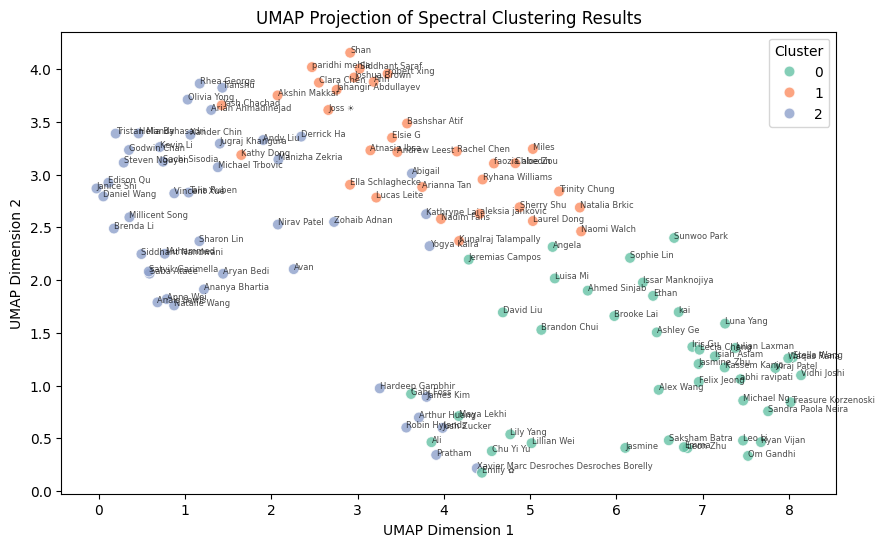

In [182]:
import umap.umap_ as umap
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### ======= STEP 8: UMAP 2D Visualization ======= ###
def visualize_umap_clusters(affinity_matrix, labels, attendee_names):
    """Plots clusters using UMAP for dimensionality reduction."""
    umap_2d = umap.UMAP(n_components=2, random_state=42)
    embedding_2d = umap_2d.fit_transform(affinity_matrix)

    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette="Set2", s=60, alpha=0.8)

    # Annotate points with attendee names
    for i, name in enumerate(attendee_names):
        plt.text(embedding_2d[i, 0], embedding_2d[i, 1], name, fontsize=6, alpha=0.7)

    plt.title("UMAP Projection of Spectral Clustering Results")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.legend(title="Cluster")
    plt.show()

print("Generating UMAP visualization...")
visualize_umap_clusters(affinity_matrix, labels, attendee_names)

Generating graph visualization...


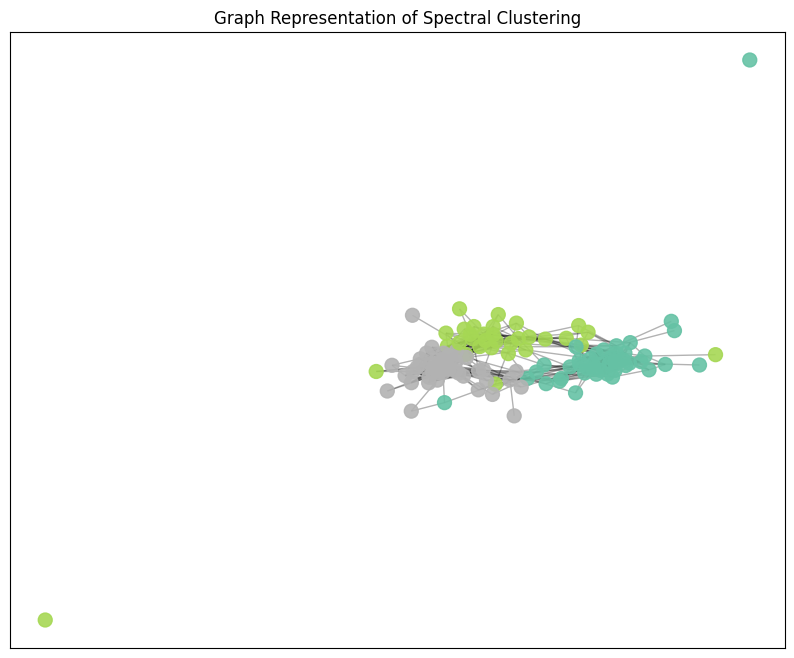

In [157]:
### ======= STEP 9: Network Graph Visualization ======= ###
def visualize_graph(affinity_matrix, labels):
    """Creates a graph visualization where nodes are attendees and edges represent strong similarities."""
    G = nx.Graph()

    # Add nodes with cluster labels
    for i in range(len(labels)):
        G.add_node(i, cluster=labels[i])

    # Add edges based on similarity (only strong connections)
    threshold = np.percentile(affinity_matrix, 90)  # Keep strongest 10% of connections
    for i in range(len(affinity_matrix)):
        for j in range(i + 1, len(affinity_matrix)):  # Avoid duplicate edges
            if affinity_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=affinity_matrix[i, j])

    # Visualize graph
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)  # Force-directed layout
    node_colors = [labels[i] for i in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2, node_size=100, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.title("Graph Representation of Spectral Clustering")
    plt.show()

print("Generating graph visualization...")
visualize_graph(affinity_matrix, labels)

In [159]:
def remap_cluster_labels(original_labels, mapping_dict):
    """
    Remaps cluster labels using the provided dictionary.
    Unmapped labels are left unchanged.
    """
    return [mapping_dict.get(label, label) for label in original_labels]
mapping_dict = {1:2,2:0,0:1}
labels = remap_cluster_labels(labels,mapping_dict)

Generating cluster distribution plot...


/tmp/ipykernel_74548/2744433363.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


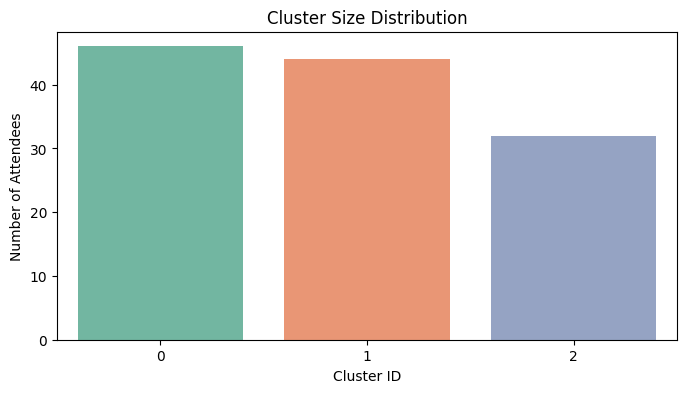

In [161]:
### ======= STEP 10: Cluster Size Distribution ======= ###
def plot_cluster_distribution(labels):
    """Plots the distribution of cluster sizes as a bar chart."""
    df_clusters = pd.DataFrame({"Cluster": labels})
    cluster_counts = df_clusters["Cluster"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Attendees")
    plt.title("Cluster Size Distribution")
    plt.show()

print("Generating cluster distribution plot...")
plot_cluster_distribution(labels)

In [162]:
### ======= STEP 11B: Export All Attendees With Clustering Info and Matches ======= ###

def export_cluster_matches(attendee_names, spectral_labels, final_merged_clusters, person_embeddings):
    """
    Creates a dictionary for each attendee with name, email, cluster labels, and small-cluster matches.
    """
    # Step 1: Assign agglomerative (small) cluster labels to each attendee
    agg_labels = [-1] * len(attendee_names)
    for cluster_id, (indices, _) in enumerate(final_merged_clusters):
        for idx in indices:
            agg_labels[idx] = cluster_id

    # Step 2: Build reverse lookup of small clusters → list of indices
    agg_cluster_map = {}
    for idx, cluster_id in enumerate(agg_labels):
        agg_cluster_map.setdefault(cluster_id, []).append(idx)

    # Step 3: Build dictionary keyed by attendee name (like your original format)
    matches_dict = {}
    for i, name in enumerate(attendee_names):
        email = person_embeddings.get(name, {}).get("email", "UNKNOWN")
        spectral_cluster = int(spectral_labels[i])
        small_cluster = int(agg_labels[i])

        # Get other attendees in the same small cluster
        match_indices = [j for j in agg_cluster_map[small_cluster] if j != i]
        matches = [
            {
                "name": attendee_names[j],
                "email": person_embeddings.get(attendee_names[j], {}).get("email", "UNKNOWN")
            }
            for j in match_indices
        ]

        matches_dict[name] = {
            "email": email,
            "house": spectral_cluster,
            "match_number": small_cluster,
            "matches": matches
        }

    return matches_dict

# Generate full cluster match data
cluster_match_data = export_cluster_matches(attendee_names, labels, final_merged_clusters, person_embeddings)

### ======= STEP 12B: Save Full Cluster Match Data to JSON File ======= ###
CLUSTER_OUTPUT_FILE = "attendee_cluster_matches.json"

with open(CLUSTER_OUTPUT_FILE, "w") as json_file:
    json.dump(cluster_match_data, json_file, indent=4)

print(f"✅ Full cluster and match data saved to {CLUSTER_OUTPUT_FILE}!")


✅ Full cluster and match data saved to attendee_cluster_matches.json!


In [163]:
def print_first_n_attendees(cluster_match_data, n=10):
    """
    Pretty-prints the first n attendees from the cluster match data.
    """
    count = 0
    for name, data in cluster_match_data.items():
        print(f"\n👤 Attendee: {name}")
        print(f"   📧 Email: {data.get('email', 'Unknown')}")
        print(f"   🔷 Spectral Cluster: {data.get('house', 'N/A')}")
        print(f"   🔶 Agglomerative Cluster: {data.get('match_number', 'N/A')}")
        print(f"   🤝 Matches ({len(data.get('matches', []))}):")
        for match in data.get("matches", []):
            print(f"     - {match['name']} ({match.get('email', 'Unknown')})")
        count += 1
        if count >= n:
            break


In [ ]:
print_first_n_attendees(cluster_match_data, n=10)


In [135]:
###--Get Answersfor each attendee in each spectral cluster organized into separate files for each cluster
import os

# Step 1: Define the 3 main questions (as renamed in your cleaned DataFrame)
main_questions = ["Learning Interest", "Past Work", "Talk Forever"]

# Step 2: Check all expected columns exist
for q in main_questions:
    if q not in df_cleaned.columns:
        raise ValueError(f"Expected column '{q}' not found in DataFrame.")

# Step 3: Create output directory
output_dir = "spectral_cluster_texts"
os.makedirs(output_dir, exist_ok=True)

# Step 4: Group attendees by spectral cluster label
from collections import defaultdict
cluster_to_rows = defaultdict(list)

for idx, cluster_id in enumerate(labels):
    row = df_cleaned.iloc[idx]
    cluster_to_rows[cluster_id].append(row)

# Step 5: For each cluster, write a file with LLM-optimized formatting
for cluster_id, rows in cluster_to_rows.items():
    output_path = os.path.join(output_dir, f"cluster_{cluster_id}.txt")
    with open(output_path, "w", encoding="utf-8") as f:
        for row in rows:
            for q in main_questions:
                answer = str(row[q]).strip()
                if answer:
                    f.write(answer + "\n")
            f.write("\n")  # Blank line between attendees

print(f"✅ Saved cluster files to '{output_dir}/', one per spectral group.")

✅ Saved cluster files to 'spectral_cluster_texts/', one per spectral group.
